# MOD510: Project 3

**Deadline: 10. November 2025 (23:59)**


**Group members**

* Simen Sæverud Gåsland

* Nataliia Aksamentova

# Abstract 
**Write here**

# Introduction
**Write here**

# Exercise 1 : Write your own ODE solver

**Intro here**

## Part 1

Below we have created a solver that solves a system of ODEs of the form: 
$$\frac{d \vec{r}}{dt} = \vec{f} \left(\vec{r}, t\right) \text{,}$$

where $\vec{r} = \left[x, y, ...\right]$ and $\vec{f} = \left[f_x \left(\vec{r}, t\right), f_y \left(\vec{r}, t\right), ...\right]$

The solver is designed to handle any generic ODE or systems of ODEs. The user must give the solver a start time $t_0$ and corresponding initial condition(s) $r_0$, as well as the final simulation time $t_f$. The user can choose from any of these four methods: 
1. Eulers method
2. Runge-Kutta second order (RK2)
3. Runge-Kutta fourth order (RK4)
4. Numba Runge-Kutta fourth order (Fast RK4)

The last method is not expected in this assignment. In the last project we were introduced to Numba to speed up parts of the code. We have therefore added a Numba version of RK4 to speed up our code, since RK4 is the method we will use for the other tasks. 

Lastly, the user can also choose an adaptive step size that ensures a local error below a set tolerance $\text{max}_\text{tol}$. 

In [1]:
import numpy as np
import math
import numba_rk4

import warnings
from numba.core.errors import NumbaExperimentalFeatureWarning
warnings.filterwarnings("ignore", category=NumbaExperimentalFeatureWarning)

class ODESolver:
    '''
    Class docstring
    '''
    def __init__(self, f, t0, tf, h, r0, method = 'rk4', max_tol = 1e-5, adaptive = True, args = ()):
        self.f = f
        self.t0 = t0
        self.tf = tf
        self.h = h
        if adaptive:
            self.n = int(1e6)
        else:
            self.n = math.ceil((tf - t0) / h)

        self.t_points = np.zeros(self.n + 2, float)
        self.r0 = np.array(r0, float)
        self.method = method
        self.choosen_method = {'euler': self.__euler,
                               'rk2': self.__rk2,
                               'rk4': self.__rk4,
                               'fast_rk4': numba_rk4.solve
                               }[method]
        self.r_points = np.zeros((self.n + 2, len(self.r0)), float)
        self.adaptive = adaptive
        self.step_exponent = {"euler":1/2, "impeuler":1/3, "rk2":1/3, "rk4":1/5, 'fast_rk4': None}[method]
        self.max_tol = max_tol
        self.args = args

    def __euler(self, t, r, h):
        '''
        Eulers method
        '''
        return r + h * self.f(r, t, *self.args)

    def __rk2(self, t, r, h):
        '''
        Runge-Kutta second order (RK2)
        '''
        k1 = self.f(r, t, *self.args)
        k2 = self.f(r + 0.5 * k1 * h, t + 0.5 * h, *self.args)
        return r + h * k2

    def __rk4(self, t, r, h):
        '''
        Runge-Kutta fourth order (RK4)
        '''
        k1 = h * self.f(r, t, *self.args)
        k2 = h * self.f(r + 0.5 * k1, t + 0.5 * h, *self.args)
        k3 = h * self.f(r + 0.5 * k2, t + 0.5 * h, *self.args)
        k4 = h * self.f(r + k3, t + h, *self.args)
        return r + (k1 + 2 * k2 + 2 * k3 + k4) / 6

    def solve(self):
        '''
        Doc string for solve function
        '''

        self.r_points[0] = self.r0
        self.t_points[0] = self.t0

        if self.choosen_method == numba_rk4.solve:
            self.t_points, self.r_points = self.choosen_method(self.f, self.h, self.t0, self.tf,
                                                           self.r0, self.t_points, self.r_points,
                                                           self.adaptive, self.max_tol, *self.args)
        else:
            h = self.h
            t = self.t0
            i = 0

            while t < self.tf:
                r_i = self.r_points[i]

                if self.adaptive:
                    r1 = self.choosen_method(t, r_i, h)

                    r_half = self.choosen_method(t, r_i, h / 2)
                    r2 = self.choosen_method(t + h / 2, r_half, h / 2)

                    Err = np.max(np.abs(r2 - r1))
                    Err = max(Err, 1e-14)
                    h = h * (self.max_tol / Err)**self.step_exponent

                h = min(h, self.tf - t)  # Do not step beyond tf/avoid overshooting
                self.r = self.choosen_method(t, r_i, h)
                self.r_points[i + 1]= self.r.copy()
                t += h
                self.t_points[i + 1]= t
                i += 1
            self.t_points = self.t_points[:i+1]
            self.r_points = self.r_points[:i+1]

        return self.t_points, self.r_points


## Part 2

Here we have written six functions. The first three are the mass conservation equations for $1$, $2$ and $3$ tanks. The last three are the corresponding analytical solutions. The **@njit** above all the functions are there to make the functions Numba compliant. 

In [2]:
from numba import njit

@njit
def cd_0(r, t, tau = 2):
    """ 1 tank"""
    n = 1
    Cin = 0 # input concentration = 0
    rp = np.zeros(len(r))
    rp[0] = (n/tau)*(Cin - r[0])
    return rp

@njit
def cd_1(r, t, tau = 2):
    """ 2 tanks"""
    n = 2
    Cin = 0 # input concentration = 0
    rp = np.zeros(len(r))
    rp[0] = (n/tau)*(Cin - r[0])
    rp[1] = (n/tau)*(r[0] - r[1])
    return rp

@njit
def cd_2(r, t, tau = 2):
    """ 3 tanks"""
    n = 3
    Cin = 0 # input concentration = 0
    rp = np.zeros(len(r))
    rp[0] = (n/tau)*(Cin - r[0])
    rp[1] = (n/tau)*(r[0] - r[1])
    rp[2] = (n/tau)*(r[1]- r[2])
    return rp

@njit
def c_0(t, tau = 2):
    return np.exp(-t / tau)

@njit
def c_1(t, tau = 2):
    return (2 * t / tau) * np.exp(-2 * t / tau)

@njit
def c_2(t, tau = 2):
    return 9* t**2 / (2 * tau**2) * np.exp(-3 * t / tau)

With these functions we can now finally test our solver against the analytical solutions. Below we have created three instances of the **ODESolver**, where all of them have the same parameters, except for the ODEs they are given. We want to make three plots for $1$, $2$ and $3$ tanks. For all of them we have chosen our **Fast RK4** solver with adaptive stepping.

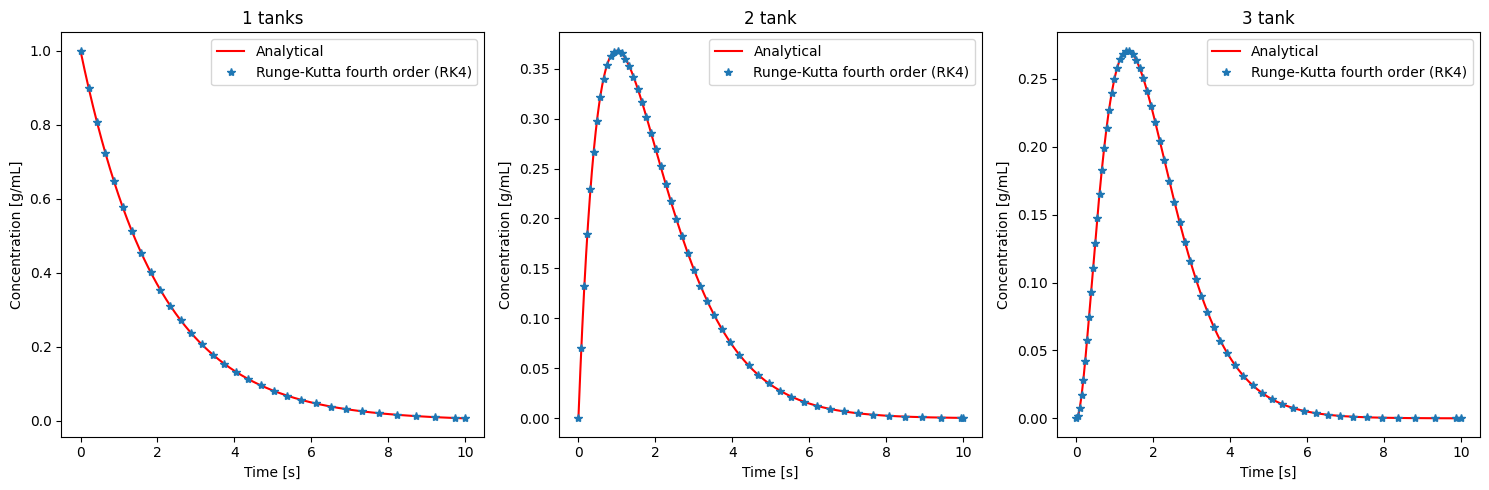

In [3]:
import matplotlib.pyplot as plt

#Setting fixed values
ta = np.linspace(0, 10, 1000)
diff_eqns = [cd_0, cd_1, cd_2]
ana_sols = [c_0, c_1, c_2]

plt.figure(figsize=(15, 5))

for i, diff_eqn in enumerate(diff_eqns):

    #Initial conditions
    r0 = np.zeros(i + 1)
    r0[0] = 1

    #Solve diff equation
    ode_solver = ODESolver(diff_eqn, 0, 10, 1e-2, r0, 'fast_rk4', 1e-7)
    times, consentrations= ode_solver.solve()

    #Plotting
    plt.subplot(1, 3, i + 1)
    plt.plot(ta, ana_sols[i](ta), '-',color = 'red', label = "Analytical")
    plt.plot(times, consentrations[:, -1], '*',label = "Runge-Kutta fourth order (RK4)")
    plt.xlabel('Time [s]')
    plt.ylabel('Concentration [g/mL]')
    plt.legend()

    #Make sure grammar is correct
    if (i + 1) > 1:
        plt.title(f'{i + 1} tank')
    else:
        plt.title(f'{i + 1} tanks')

plt.tight_layout()
plt.show()

From the plots above we can see that they match the analytical solutions very well. We can also see that the adaptive stepping is working as intended. This is especially noticeable in the plot for $2$ and $3$ tanks, where you can see larger steps in the beginning and then shorter steps at the peaks. 


Before we move on, we would also like to demonstrate why we have implemented a Numba solver. The first time using the **Fast RK4** solver it will be noticeably slower, but after that first run the Numba version will be considerably faster. It is for very large systems we can really see the effect of Numba.    

In [4]:
import timeit

number = 10
cake = ODESolver(cd_2, 0, 10, 1e-3, [1, 0, 0], 'fast_rk4', adaptive = False)
cake2 = ODESolver(cd_2, 0, 10, 1e-3, [1, 0, 0], 'rk4', adaptive = False)

t = timeit.timeit(lambda: cake.solve(), number = number) / number
t2 = timeit.timeit(lambda: cake2.solve(), number = number) / number

print(f"With Numba: {t}s")
print(f"Without Numba: {t2}s")
print(f"With Numba is {t2/t:.2f} times faster")

With Numba: 0.006957720000355039s
Without Numba: 0.2204016900002898s
With Numba is 31.68 times faster


## Part 3

To analyze the numerical error at $t = 1$ we have chosen the mass conservation equation for $3$ tanks. We will below plot the numerical error for $\Delta t$ values in the range $\left[0.1, 10^{-4} \right]$. For the different methods we expect the following errors: 
$$\text{Euler error} = \mathcal{O}\left( \Delta t\right) \quad \quad \text{RK2 error} = \mathcal{O}\left( \Delta t^2\right) \quad \quad \text{RK4 error} = \mathcal{O}\left( \Delta t^4\right)$$

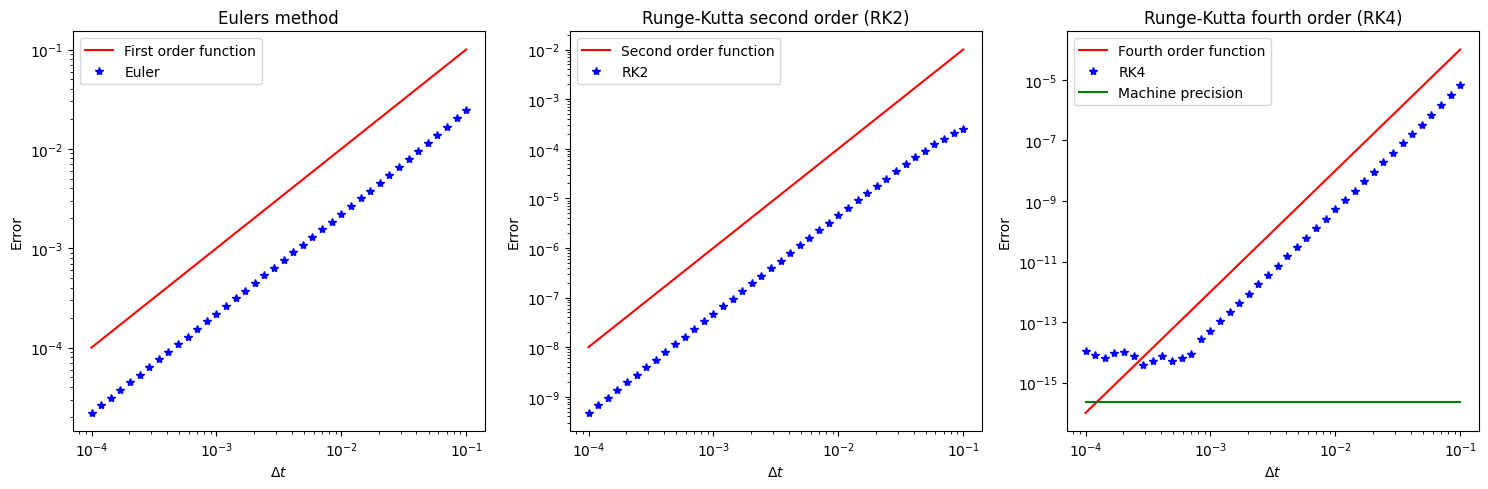

In [5]:
import sys

dts = np.logspace(-1, -4, 40)
euler_error = []
rk2_error = []
rk4_error =[]
r0 = np.array([1, 0, 0])
machine_precision = np.ones(len(dts)) * sys.float_info.epsilon

for _, dt in enumerate(dts):
    ode_solver_euler = ODESolver(f = cd_2, t0 = 0, tf = 1, h = dt, r0 = r0, method = 'euler', adaptive = False)
    ode_solver_rk2 = ODESolver(f = cd_2, t0 = 0, tf = 1, h = dt, r0 = r0, method = 'rk2', adaptive = False)
    ode_solver_rk4 = ODESolver(f = cd_2, t0 = 0, tf = 1, h = dt, r0 = r0, method = 'fast_rk4', adaptive = False)

    t_euler, c_euler = ode_solver_euler.solve()
    t_rk2, c_rk2 = ode_solver_rk2.solve()
    t_rk4, c_rk4 = ode_solver_rk4.solve()

    euler_error.append(np.abs(c_2(t_euler[-1]) - c_euler[-1, -1]))
    rk2_error.append(np.abs(c_2(t_rk2[-1]) - c_rk2[-1, -1]))
    rk4_error.append(np.abs(c_2(t_rk4[-1]) - c_rk4[-1, -1]))

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.loglog(dts, dts, color = 'red', label = 'First order function')
plt.loglog(dts, euler_error, '*', color = 'blue', label = 'Euler')
plt.ylabel('Error')
plt.xlabel(r'$\Delta t$')
plt.title('Eulers method')
plt.legend()

plt.subplot(1, 3, 2)
plt.loglog(dts, dts**2, color = 'red', label = 'Second order function')
plt.loglog(dts, rk2_error, '*', color = 'blue', label = 'RK2')
plt.ylabel('Error')
plt.xlabel(r'$\Delta t$')
plt.title('Runge-Kutta second order (RK2)')
plt.legend()

plt.subplot(1, 3, 3)
plt.loglog(dts, dts**4, color = 'red', label = 'Fourth order function' )
plt.loglog(dts, rk4_error, '*', color = 'blue', label = 'RK4')
plt.loglog(dts, machine_precision, '-', color = 'green', label = 'Machine precision')
plt.ylabel('Error')
plt.xlabel(r'$\Delta t$')
plt.title('Runge-Kutta fourth order (RK4)')
plt.legend()

plt.tight_layout()
plt.show()

As you can see from the plots above, we get what we expected. Eulers method is parallel to a first order function, and RK2 is parallel to a second order function. For the RK4 on the other hand we see something strange. For higher values of $\Delta t$ the error is parallel to a fourth order function as we expected, but as $\Delta t$ gets closer to the machine precision we can see that round off errors start to dominate. 

# Exercise 2: Fit CSTR model to CFD model: Healthy aorta

**Intro here**

## Part 1

To find the volumetric injection flow rate $q$ we must solve the following equation: 
$$q = \frac{M_{inj}}{\int_0^\infty C_{out}(t)\text{dt}}$$

But before we start solving, we have to make sure our units are correct. We want $q$ to be measured in $L/min$, $M_{inj}$ is given to us in grams, and $C_{out}$ is in $g/mL$ which gets multiplied with $s$ after the integration. Below you can see the calculations made to determine that we need to multiply $q$ with $\frac{6}{100}$ after we have performed calculations to get the right unit.

$$\frac{\cancel{g}}{\frac{\cancel{g}}{mL} \cdot s} \quad \Rightarrow \quad \frac{1}{\frac{s}{mL}} \quad \Rightarrow \quad \frac{mL}{s} \quad \Rightarrow \quad \frac{\cancel{mL} \cdot \frac{1 L}{1000 \cancel{mL}}}{\cancel{s} \cdot \frac{1min}{60 \cancel{s}}} \quad \Rightarrow \quad \frac{\frac{1}{1000} L}{\frac{1}{60}min} \quad \Rightarrow \quad \frac{6}{100}\frac{L}{min}

The injected mass is given as $M_{inj} = 83.333 g$, and the concentration $C_{out}$ we get from the CFD data. So below we import CFD data for a healthy aorta with injection protocol **rect 1s**, then we integrate this data using NumPy’s **trapezoid** function. This function integrates the data using the trapezoidal rule (https://numpy.org/doc/2.3/reference/generated/numpy.trapezoid.html). After this we simply use the formula for $q$. 

In [6]:
import pandas as pd

#Import CFD data
c_out = pd.read_csv('Data/Healthy_rect_1s.csv', sep = ',')

concentrations = np.array(c_out['Concentration']) #[g/mL]
times = np.array(c_out['Time']) #[s]

#Preforms integral in denominator
int_c_out = np.trapezoid(concentrations, times)

#Injected mass
m_inj = 83.333 #[g]

#Preform calculations
q = m_inj / int_c_out

#Unit conversion
q = q * (6 / 100) #[L/min]

print(f'The volumetric injection flow rate q is {q:.2f} L/min')


The volumetric injection flow rate q is 5.01 L/min


We get a volumetric injection flow rate of $5$ L/min as expected. 

## Part 2

In the assignment there are six different injection protocols, we have below recreated all six. They have all been created using the **where** function from NumPy. This function takes in a condition, and if the condition is True the function returns the second element, and if False it returns the third element (https://numpy.org/doc/2.2/reference/generated/numpy.where.html). So for the **rect 1s** when is $t <1$, $t$ is set to $1$. When $t>1$, $t$ is set to $0$. 

Note that the first time run of the code below might be slow because of **@njit** that makes them Numba compatible. 

In [7]:
@njit
def rect_1s(t):
    return np.where(t < 1, 1, 0)

@njit
def rect_2s(t):
    return np.where(t < 2, 1, 0)

@njit
def rect_3s(t):
    return np.where(t < 3, 1, 0)

@njit
def ramp_1s(t):
    return np.where(t < 1, t, 0)

@njit
def ramp_2s(t):
    return np.where(t < 2, t/2, 0)

@njit
def biphasic(t):
    return (
        np.where((t < 1), 0.7, 0) +
        np.where((t > 2) & (t < 3), 1, 0)
    )


To confirm that we have implemented the protocol correctly, we plot all six and compare them to figure $5$ in the assignment.

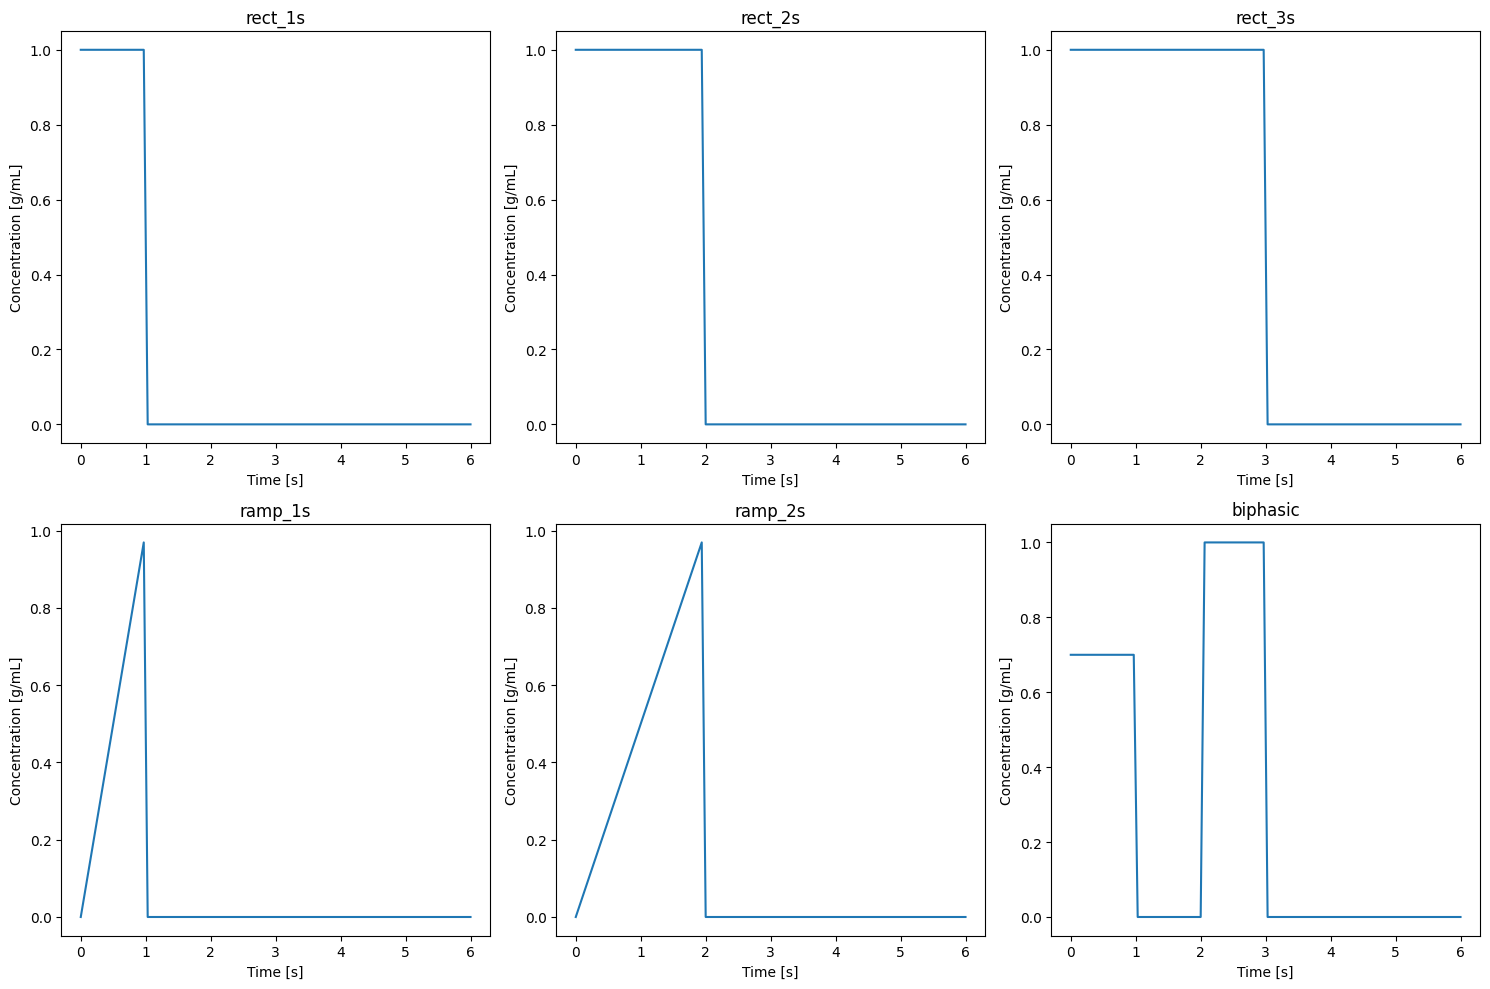

In [8]:
#Intializing time axis and injection protocols to plot
t = np.linspace(0, 6, 100)
inj_pros = [rect_1s, rect_2s, rect_3s, ramp_1s, ramp_2s, biphasic]

plt.figure(figsize=(15, 10))

#Plotting
for i, inj_pro in enumerate(inj_pros):
    plt.subplot(2, 3, i + 1)
    plt.plot(t, inj_pro(t))
    plt.xlabel('Time [s]')
    plt.ylabel('Concentration [g/mL]')
    plt.title(inj_pro.__name__)

plt.tight_layout()
plt.show()


All the plots match figure $5$ in the assignment. 

## Part 3

In exercise $1$ part $2$ we created three functions for the mass conservation equation. These functions have hard coded the number of tanks. For this part we need a more generic function where we can modify the number of tanks. We have therefore created an improved function that takes in a parameter $n$ for the number of tanks. We also allowed the user to change the injection protocol, which is a functionality that will come in handy later.

In [9]:
@njit
def cd_n(r, t, n_tanks, tau, inj_pro = rect_1s):
    c_in = inj_pro(t)
    rp = np.zeros(n_tanks)

    for i in range(n_tanks):
        if i == 0:
            rp[0] =  (n_tanks/tau) * (c_in- r[i])
        else:
            rp[i] =  (n_tanks/tau) * (r[i - 1] - r[i])
    return rp

To find the "best match" of $V_{tot}$ we have of course chosen the "hard" method, where we have to find the minimal Sum of Squared Residuals (SSR) using one of the minima finding algorithms covered in class.

In [10]:
#Number of tanks, this is adjusted manually
n_tanks = 52

#Initial conditions
r0 = np.zeros(n_tanks)

#Import data
data = pd.read_csv('Data/Healthy_rect_1s.csv')
t_data = data['Time'].to_numpy()
c_data = data['Concentration'].to_numpy()

#Calculate Sum of Squared Residuals (SSR)
def ssr(tau):
    solver = ODESolver(f=cd_n, t0=0, tf=5, h=1e-3, r0=r0,
                   method='fast_rk4', adaptive=False,
                   args=(n_tanks, tau))
    t_model, c_model = solver.solve()
    c_out = np.interp(t_data, t_model, c_model[:, -1])
    return np.sum((c_data - c_out) ** 2)

#Derivative of SSR
def d_ssr(tau, delta_tau = 1e-3):
    return (ssr(tau + delta_tau) - ssr(tau)) / (2*delta_tau)


With SSR and the derivative of SSR implemented, we "cheat" to get an indication which value of $\tau$ gives the smallest SSR. The reason we are interested in finding $\tau$ when our goal is to find $V_{tot}$ is because $\tau = \frac{V_{tot}}{q}$ and $q$ is known. Depending on the minima finding algorithm we choose we now get an indication of an initial guess or value range. 

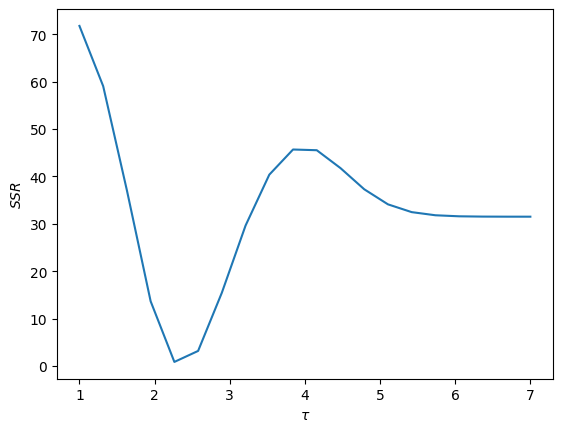

In [11]:
#Do not need a very fine grid
tau_values = np.linspace(1, 7, 20)
ssr_values = []

#Calculating SSR values based on tau
for tau in tau_values:
    ssr_values.append(ssr(tau))

#Plotting
plt.plot(tau_values, ssr_values)
plt.xlabel(r'$\tau$')
plt.ylabel('$SSR$')
plt.show()

When it came time to choose the minima finding algorithm, we considered quite a few options. We first tried out the bisection method since it is a safe option. However, it proved to be terribly slow, which is expected since it only converges linearly. Our implementation of the bisection method, which is not included in this report, took around 17 seconds to find the minima. This is not horrible, but it is not great. For more speed we look at Newtons method, which converges quadratically. Unfortunately, this method requires us to calculate the second derivative of SSR. Therefore, the secant method (often called quasi-Newton method) seemed like a better option. The secant method almost the same as the Newton method, but here we replace the second derivative with a finite difference approximation. This way we do not have to manually calculate the second derivative, and the secant method almost converges quadratically (the order of conversion is the golden ratio $\varphi \approx 1.618$) (https://en.wikipedia.org/wiki/Secant_method) (**ref: Gezerlis og Hiorth**). 

In [12]:
def secant_method(fd, x0, x1, prec = 1e-8, max_iter = 20):
    '''
    Finds an extremum of f(x) using the secant method
    '''
    fd0 = fd(x0)
    for i in range(1, max_iter):
        fd1 = fd(x1)
        ratio = (x1 - x0) / (fd1 - fd0)
        x2 = x1 - fd1 * ratio

        xdiff = abs(x2 - x1)
        x0, x1 = x1, x2
        fd0 = fd1

        if abs(xdiff / x2) < prec:
            break
    else:
        x2 = None

    return x2, i

In [13]:
best_tau, iter = secant_method(fd = d_ssr, x0 = 1, x1 = 3, prec = 1e-8, max_iter = 100)
print(f'Found τ = {best_tau:.2f} after {iter} iterations')
print(f'With τ = {best_tau:.2f} we get d(ssr)/dτ = {d_ssr(best_tau):.2f}')

Found τ = 2.36 after 7 iterations
With τ = 2.36 we get d(ssr)/dτ = 0.00


After $7$ iterations we find that $\tau = 2.36$ gives the minimal SSR-value. Now we only have to find the number of tanks that give the best fit. This is done simply by just testing different values of $n$. 

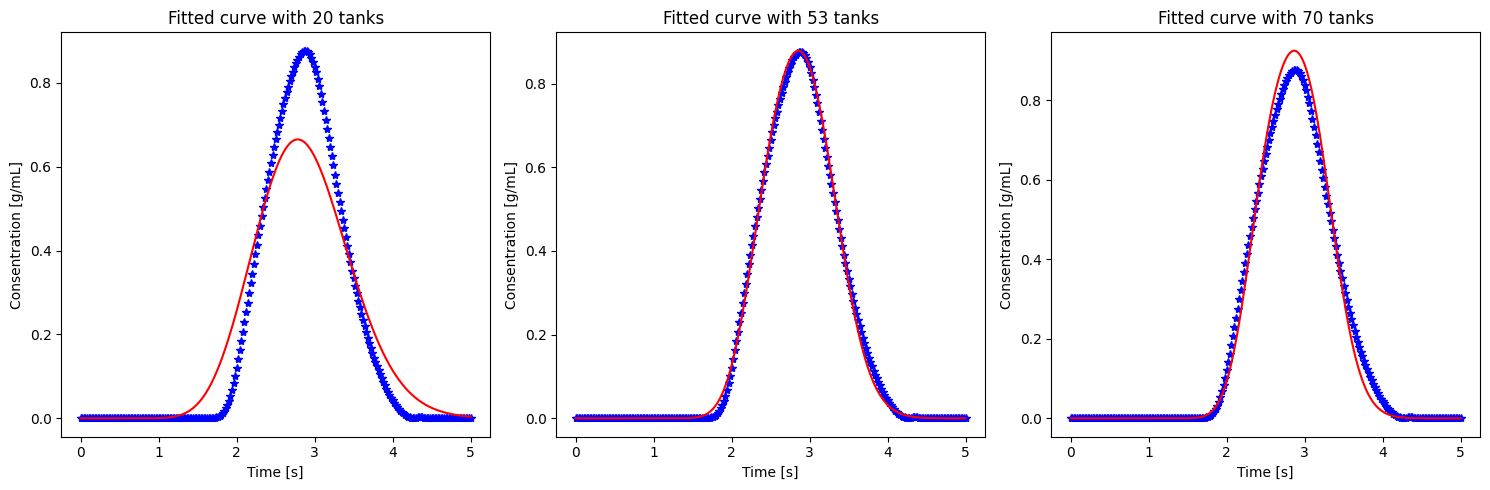

In [14]:
#Testing different number of tanks
n_tanks = [20, 53, 70]

plt.figure(figsize=(15, 5))
for i, tanks in enumerate(n_tanks):

    #Inital condition
    r0 = np.zeros(tanks)

    #Solve mass conservation equation for different number of tanks
    solver = ODESolver(f=cd_n, t0=0, tf=5, h=1e-3, r0=r0,
                    method='fast_rk4', adaptive=False, args=(tanks, best_tau))
    t_model, c_model = solver.solve()

    #Plotting
    plt.subplot(1, 3, i + 1)
    plt.plot(t_data, c_data, '*', color = 'blue')
    plt.plot(t_model, c_model[:,-1],'-', color = 'red')
    plt.xlabel('Time [s]')
    plt.ylabel('Consentration [g/mL]')
    plt.title(f'Fitted curve with {tanks} tanks')

plt.tight_layout()
plt.show()


From the plots above you can see that the best number of tanks $n$ that gives the best fit is $n = 53$. 

With this we can now estimate the volume of the aorta by using $\tau = 2.36 s$ and $q = 5 L/min$

In [15]:
#Calculating V_tot in mL
v_tot = best_tau * q *(100/6)
print(f"The 'best match' V_tot is {v_tot:.2f}mL with τ = {best_tau:.2f}s and q = {q:.2f}L/min")

The 'best match' V_tot is 197.28mL with τ = 2.36s and q = 5.01L/min


Since we are not medical students, a quick Google search is preformed to see if our answer is physically accurate. And what we found is that the median aortic volume is $194mL$, so our answer is at least not physically impossible https://pmc.ncbi.nlm.nih.gov/articles/PMC6940405/). 

## Part 4

In the last part we used the **rect 1s** injection protocol to tune our model. In this part we keep the value of $V_tot$ and $n$ the same to see how good our model is at predicting other injection protocols.

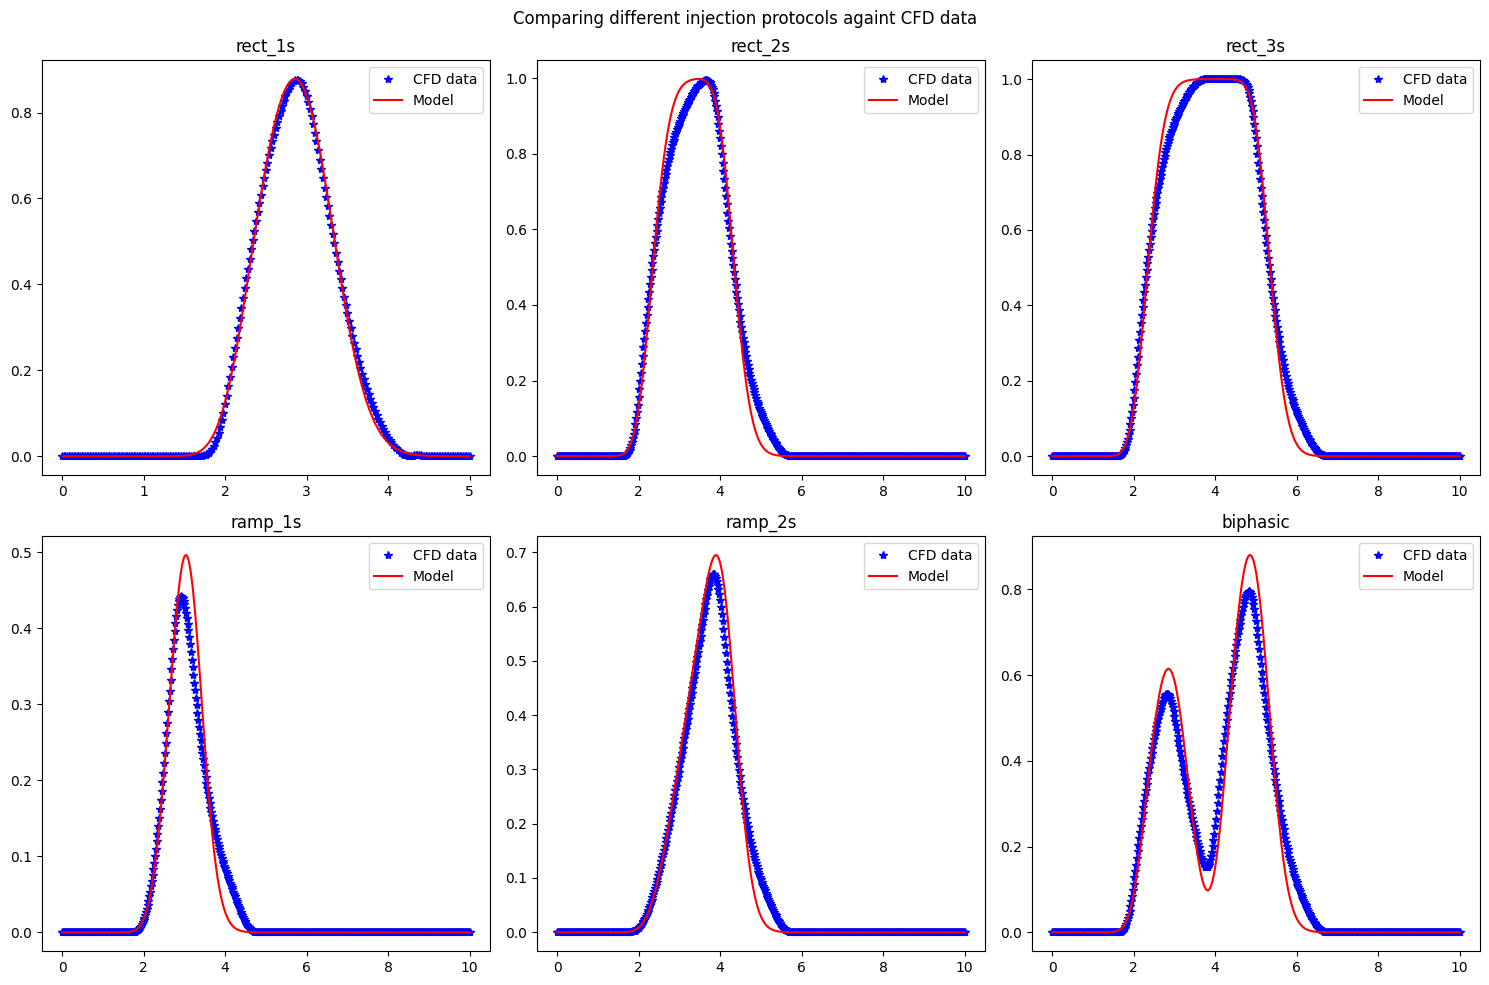

In [16]:
#Fixed values
n_tanks = 53
r0 = np.zeros(n_tanks)
tau = best_tau.copy()
inj_pros = [rect_1s, rect_2s, rect_3s, ramp_1s, ramp_2s, biphasic]

#Labels for plot
cdf_label = 'CFD data'
model_label = 'Model'

plt.figure(figsize=(15, 10))

for i, inj_pro in enumerate(inj_pros):

    #Injection protocal as type string
    inj_pro_str = inj_pro_str = inj_pro.__name__

    #Only rect_1s has time range [0-5]
    #The rest has time range [0-10]
    if i > 0:
        tf = 10
    else:
        tf = 5

    #Numerical model
    solver= ODESolver(f=cd_n, t0=0, tf=tf, h=1e-2, r0=r0,
                   method='fast_rk4', adaptive=False, args=(n_tanks, tau, inj_pro))
    t_model, c_model = solver.solve()

    #Getting data
    data = pd.read_csv(f'Data/Healthy_{inj_pro_str}.csv')
    t_data = data['Time'].to_numpy()
    c_data = data['Concentration'].to_numpy()

    #Plotting
    plt.subplot(2, 3, i + 1)
    plt.plot(t_data, c_data, '*', color = 'blue', label = cdf_label)
    plt.plot(t_model, c_model[:, -1],'-', color = 'red', label = model_label )
    plt.title(inj_pro_str)
    plt.legend()

plt.suptitle('Comparing different injection protocols againt CFD data')
plt.tight_layout()
plt.show()


The results show that the model fits good for all injection protocols. For the other **rect** protocols the model captures the main peak position and shape very accurately. We can see slight differences in the peak and decline regions. As for the **ramp** and **biphasic** protocols, the model overestimates the peaks and here we can see that model here as well struggles with the decline regions. 

# Exercise 3: Fit CSTR model to CFD model: Aorta with aneurysm

**Intro here**

## Part 1

In [17]:
#Number of tanks, this is adjusted manually
n_tanks = 20

#Initial conditions
r0 = np.zeros(n_tanks)

#Import data
data_a = pd.read_csv('Data/Aneurysm_rect_1s.csv')
t_data_a = data_a['Time'].to_numpy()
c_data_a = data_a['Concentration'].to_numpy()

#Calculate Sum of Squared Residuals (SSR)
def ssr(tau):
    solver = ODESolver(f=cd_n, t0=0, tf=5, h=1e-3, r0=r0,
                   method='fast_rk4', adaptive=False,
                   args=(n_tanks, tau))
    t_model_a, c_model_a = solver.solve()
    c_out_a = np.interp(t_data_a, t_model_a, c_model_a[:, -1])
    return np.sum((c_data_a - c_out_a) ** 2)

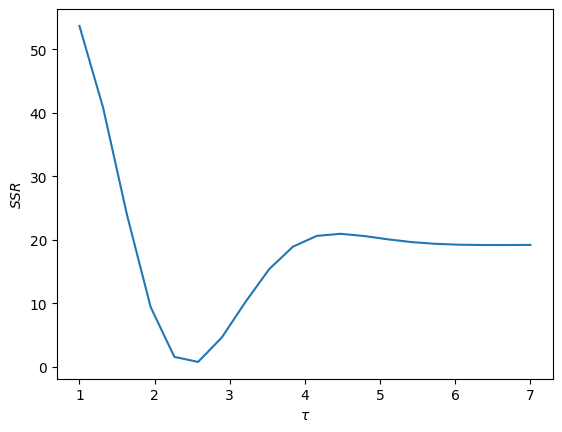

In [18]:
#Do not need a very fine grid
tau_values = np.linspace(1, 7, 20)
ssr_values = []

#Calculating SSR values based on tau
for tau in tau_values:
    ssr_values.append(ssr(tau))

#Plotting
plt.plot(tau_values, ssr_values)
plt.xlabel(r'$\tau$')
plt.ylabel('$SSR$')
plt.show()

In [19]:
best_tau_a, iter = secant_method(fd = d_ssr, x0 = 1, x1 = 3, prec = 1e-8, max_iter = 100)
print(f'Found τ = {best_tau_a:.2f} after {iter} iterations')
print(f'With τ = {best_tau_a:.2f} we get d(ssr)/dτ = {d_ssr(best_tau_a):.2f}')
ssr_exercise3 = ssr(best_tau_a)

Found τ = 2.46 after 7 iterations
With τ = 2.46 we get d(ssr)/dτ = -0.00


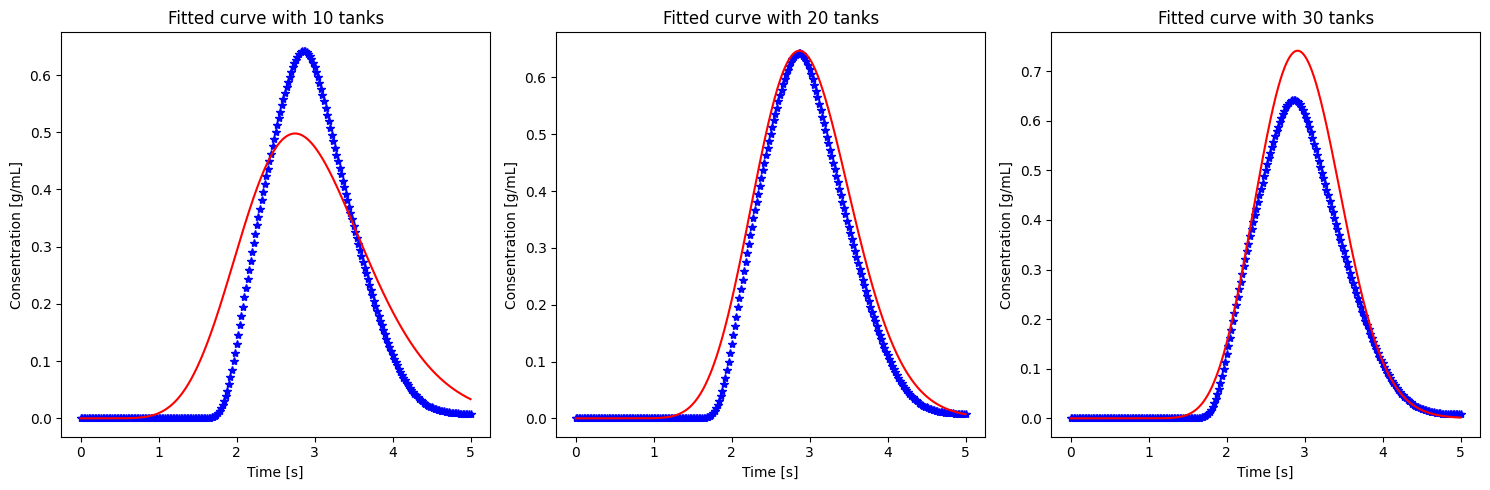

In [20]:
#Testing different number of tanks
n_tanks = [10, 20, 30]

plt.figure(figsize=(15, 5))

for i, tanks in enumerate(n_tanks):

    #Inital condition
    r0 = np.zeros(tanks)

    #Solve mass conservation equation for different number of tanks
    solver = ODESolver(f=cd_n, t0=0, tf=5, h=1e-3, r0=r0,
                    method='fast_rk4', adaptive=False, args=(tanks, best_tau_a))
    t_model_a, c_model_a = solver.solve()

    #Plotting
    plt.subplot(1, 3, i + 1)
    plt.plot(t_data_a, c_data_a, '*', color = 'blue')
    plt.plot(t_model_a, c_model_a[:,-1],'-', color = 'red')
    plt.xlabel('Time [s]')
    plt.ylabel('Consentration [g/mL]')
    plt.title(f'Fitted curve with {tanks} tanks')

plt.tight_layout()
plt.show()

In [21]:
v_tot_a = best_tau_a * q *(100/6)
print(f"The 'best match' V_tot is {v_tot_a:.2f}mL with τ = {best_tau_a:.2f}s and q = {q:.2f}L/min")

The 'best match' V_tot is 204.95mL with τ = 2.46s and q = 5.01L/min


## Part 2

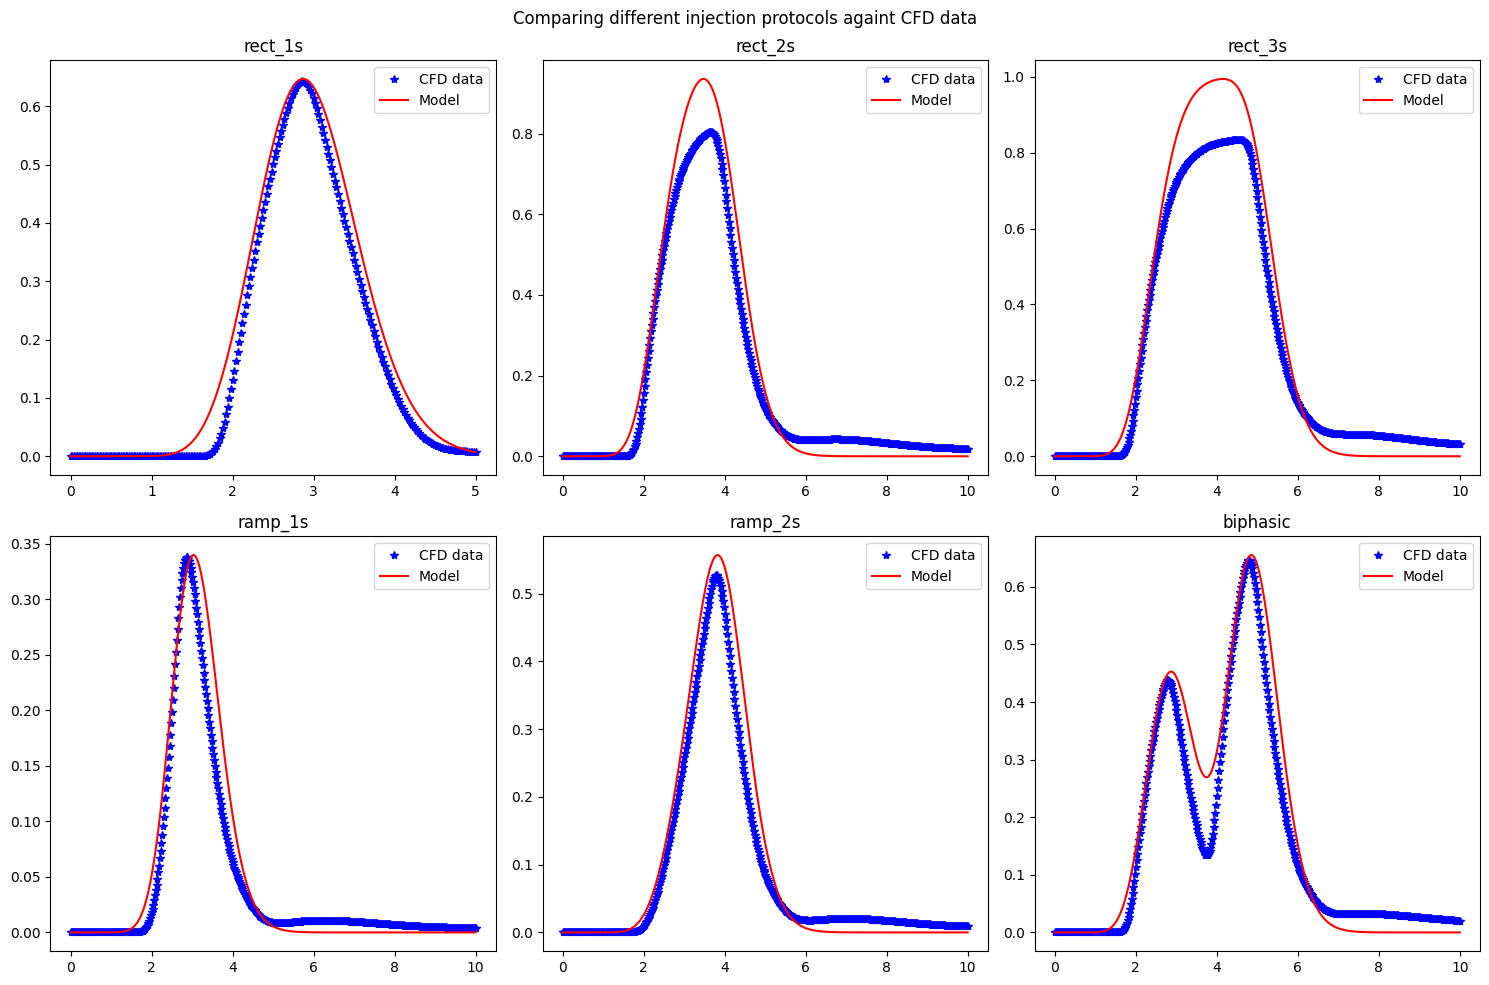

In [22]:
#Fixed values
n_tanks = 20
r0 = np.zeros(n_tanks)
inj_pros = [rect_1s, rect_2s, rect_3s, ramp_1s, ramp_2s, biphasic]

#Labels for plot
cdf_label = 'CFD data'
model_label = 'Model'

plt.figure(figsize=(15, 10))

for i, inj_pro in enumerate(inj_pros):

    #Injection protocal as type string
    inj_pro_str = inj_pro_str = inj_pro.__name__

    #Only rect_1s has time range [0-5]
    #The rest has time range [0-10]
    if i > 0:
        tf = 10
    else:
        tf = 5

    #Numerical model
    solver= ODESolver(f=cd_n, t0=0, tf=tf, h=1e-3, r0=r0,
                   method='fast_rk4', adaptive=False, args=(n_tanks, best_tau_a, inj_pro))
    t_model_a, c_model_a = solver.solve()

    #Getting data
    data_a = pd.read_csv(f'Data/Aneurysm_{inj_pro_str}.csv')
    t_data_a = data_a['Time'].to_numpy()
    c_data_a = data_a['Concentration'].to_numpy()

    #Plotting
    plt.subplot(2, 3, i + 1)
    plt.plot(t_data_a, c_data_a, '*', color = 'blue', label = cdf_label)
    plt.plot(t_model_a, c_model_a[:, -1],'-', color = 'red', label = model_label )
    plt.title(inj_pro_str)
    plt.legend()

plt.suptitle('Comparing different injection protocols againt CFD data')
plt.tight_layout()
plt.show()

## Part 3

**Reflect here**

## Part 4 

**Reflect here**

# Exercise 4 (OPTIONAL): Extend model

$$\textcolor{red}{\text{This exercise is not completed, I am stuck :(}}$$

**Intro here**

## Part 1

In [23]:
def new_cd_n(r, t, n_tanks, q, v_tot, d, v_a, inj_pro = rect_1s):
    c_in = inj_pro(t)
    rp = np.zeros(n_tanks + 1, float)
    v = v_tot / n_tanks

    C = r[: n_tanks]
    C_a = r[n_tanks]

    #Main tanks
    for i in range(n_tanks):
        if i == 0:
            rp[i] =  (q / v) * (c_in- C[i])
        elif i < n_tanks - 1:
            rp[i] =  (q / v) * (C[i - 1] - C[i])
        else:
            rp[i] = (q / v) * (C[i - 1] - C[i]) - (d / v) * (C[i] - C_a)

    #Extra tank???
    rp[n_tanks] = (d / v_a) * (C[n_tanks - 1] - C_a)

    return rp

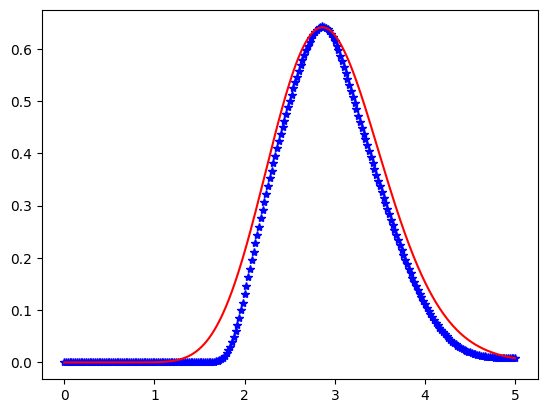

In [24]:
n_tanks = 20
r0 = np.zeros(n_tanks + 1, float)
v_a = v_tot_a - v_tot #mL
q = q * (1000 / 60) #mL/s
d = 10 * q #mL/s

data_a = pd.read_csv('Data/Aneurysm_rect_1s.csv')
t_data_a = data_a['Time'].to_numpy()
c_data_a = data_a['Concentration'].to_numpy()

solver = ODESolver(f=new_cd_n, t0=0, tf=5, h=1e-3, r0=r0,
                   method='rk4', adaptive=False, args=(n_tanks, q, v_tot, d, v_a))
new_t_model_a, new_c_model_a = solver.solve()


plt.plot(t_data_a, c_data_a, '*', color = 'blue')
plt.plot(new_t_model_a, new_c_model_a[:, n_tanks - 1],'-', color = 'red')
plt.show()

In [25]:
from scipy.optimize import curve_fit
import numpy as np

def model_output(t, d, v_a):
    r0 = np.zeros(n_tanks + 1, float)
    solver = ODESolver(
        f=new_cd_n, t0=0, tf=5, h=1e-3, r0=r0,
        method='rk4', adaptive=True,
        args=(n_tanks, q, v_tot, d, v_a)
    )
    t_model, c_model = solver.solve()
    c_out = np.interp(t, t_model, c_model[:, n_tanks - 1])
    return c_out

d_guess = q * 10 #mL/s
v_a_guess = 10 #mL

p0 = [d_guess, v_a_guess]
popt, pcov = curve_fit(
    model_output,
    t_data_a,
    c_data_a,
    p0=p0,
    bounds=([0, 0], [np.inf, np.inf])
)

d_best, v_a_best = popt
print(f"Best fit: d = {d_best:.2f}mL/s, v_a = {v_a_best:.2f}mL")

Best fit: d = 955.91mL/s, v_a = 6.73mL


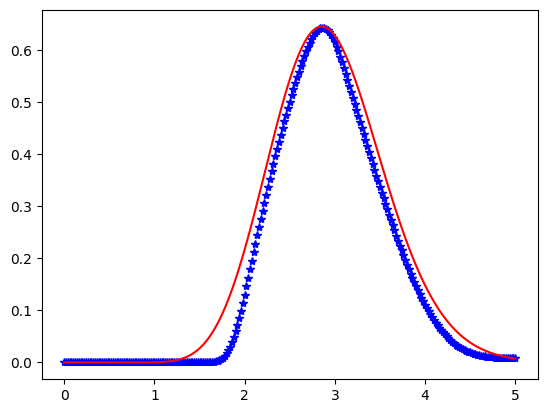

In [26]:
solver = ODESolver(
        f=new_cd_n, t0=0, tf=5, h=1e-3, r0=r0,
        method='rk4', adaptive=False,
        args=(n_tanks, q, v_tot, d_best, v_a_best)
    )
fitted_t_model, fitted_c_model = solver.solve()

plt.plot(t_data_a, c_data_a, '*', color = 'blue')
plt.plot(fitted_t_model, fitted_c_model[:, n_tanks - 1],'-', color = 'red')
plt.show()

In [27]:
#Calc ssr for fitted
c_out_fitted  = np.interp(t_data_a, fitted_t_model, fitted_c_model[:, n_tanks - 1])
ssr_fitted = np.sum((c_data_a - c_out_fitted) ** 2)

print(ssr_fitted)
print(ssr_exercise3)

print(ssr_exercise3 - ssr_fitted)

0.38539288826969265
0.3762960780560146
-0.00909681021367803
